# Double-pipe heat exchanger: 2D finite-difference


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# domain and grid
Lx, Ly = 8.0, 2.0
nx, n_cold, n_wall, n_hot = 160, 20, 6, 20

ny = n_cold + n_wall + n_hot
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)
dx, dy = x[1] - x[0], y[1] - y[0]
cold = slice(0, n_cold)
wall = slice(n_cold, n_cold + n_wall)
hot = slice(n_cold + n_wall, ny)
zone = np.zeros((ny, nx), dtype=int)   # 0 cold, 1 wall, 2 hot
zone[wall] = 1
zone[hot] = 2

Solver (explicit FDM, harmonic-mean diffusivity, first-order upwind)

In [2]:
def solve(Re, Pr=8.0, ks_kf=10.0, counter_flow=True, max_iter=12000, tol=1e-8, safety=0.4):
    # velocity: parabolic in channels, zero in wall
    eta = lambda n: np.linspace(0, 1, n)
    u = np.zeros((ny, nx))
    u[cold] = (-1 if counter_flow else 1) * (6 * eta(n_cold) * (1 - eta(n_cold)))[:, None]
    u[hot] = (6 * eta(n_hot) * (1 - eta(n_hot)))[:, None]

    # diffusivity: 1/(Re*Pr) in fluid, ks/kf times that in wall
    D = np.full((ny, nx), 1 / (Re * Pr))
    D[wall] *= ks_kf

    def bc(T):
        T[hot, 0] = 1.0
        T[hot, -1] = T[hot, -2]
        if counter_flow:
            T[cold, -1] = 0.0
            T[cold, 0] = T[cold, 1]
        else:
            T[cold, 0] = 0.0
            T[cold, -1] = T[cold, -2]
        T[wall, 0] = T[wall, 1]
        T[wall, -1] = T[wall, -2]
        T[0, :] = T[1, :]
        T[-1, :] = T[-2, :]
        return T

    harm = lambda a, b: 2 * a * b / (a + b)

    def step(T, dt):
        C = T[1:-1, 1:-1]
        E, W, N, S = T[1:-1, 2:], T[1:-1, :-2], T[2:, 1:-1], T[:-2, 1:-1]
        Dc = D[1:-1, 1:-1]
        De, Dw = harm(Dc, D[1:-1, 2:]), harm(Dc, D[1:-1, :-2])
        Dn, Ds = harm(Dc, D[2:, 1:-1]), harm(Dc, D[:-2, 1:-1])
        diff = (De * (E - C) - Dw * (C - W)) / dx**2 + (Dn * (N - C) - Ds * (C - S)) / dy**2
        uc = u[1:-1, 1:-1]
        dTdx = np.where(uc >= 0, (C - W) / dx, (E - C) / dx)   # upwind
        Tn = T.copy()
        Tn[1:-1, 1:-1] = C + dt * (diff - uc * dTdx)
        return Tn

    dt = safety * min(1 / (2 * D.max() * (1 / dx**2 + 1 / dy**2)), dx / np.abs(u).max())

    T = np.zeros((ny, nx))
    T[hot] = 1.0
    T[wall] = np.linspace(0, 1, n_wall)[:, None]
    T = bc(T)

    history = []
    for it in range(1, max_iter + 1):
        Tn = bc(step(T, dt))
        res = np.abs(Tn - T).max()
        history.append(res)
        T = Tn
        if res < tol and it > 50:
            break

    def bulk(rows, col):
        return np.average(T[rows, col], axis=0, weights=np.abs(u[rows, col]) + 1e-12)

    c_in, c_out = (-1, 0) if counter_flow else (0, -1)
    mdot = dy * np.abs(u[hot, 0]).sum()
    q_hot = mdot * (bulk(hot, 0) - bulk(hot, -1))
    q_cold = mdot * (bulk(cold, c_out) - bulk(cold, c_in))
    return dict(T=T, u=u, iters=it, res=res, history=history,
                hot_out=bulk(hot, -1), cold_out=bulk(cold, c_out),
                q_hot=q_hot, q_cold=q_cold, eff=q_cold / mdot,
                hot_bulk=bulk(hot, slice(None)), cold_bulk=bulk(cold, slice(None)))

Reference case and its plots

iterations = 11187, residual = 9.99e-09
hot outlet = 0.9432, cold outlet = 0.0568
q_hot = 0.04785, q_cold = 0.04785, effectiveness = 0.0568


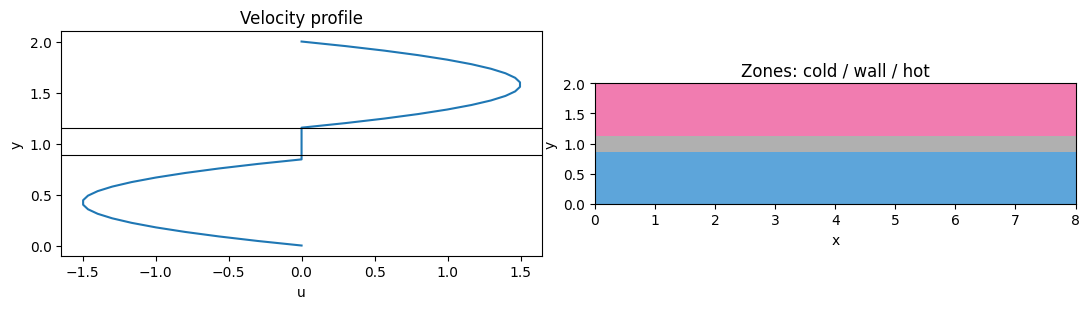

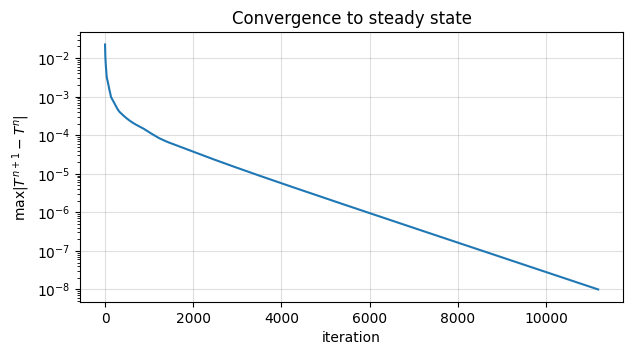

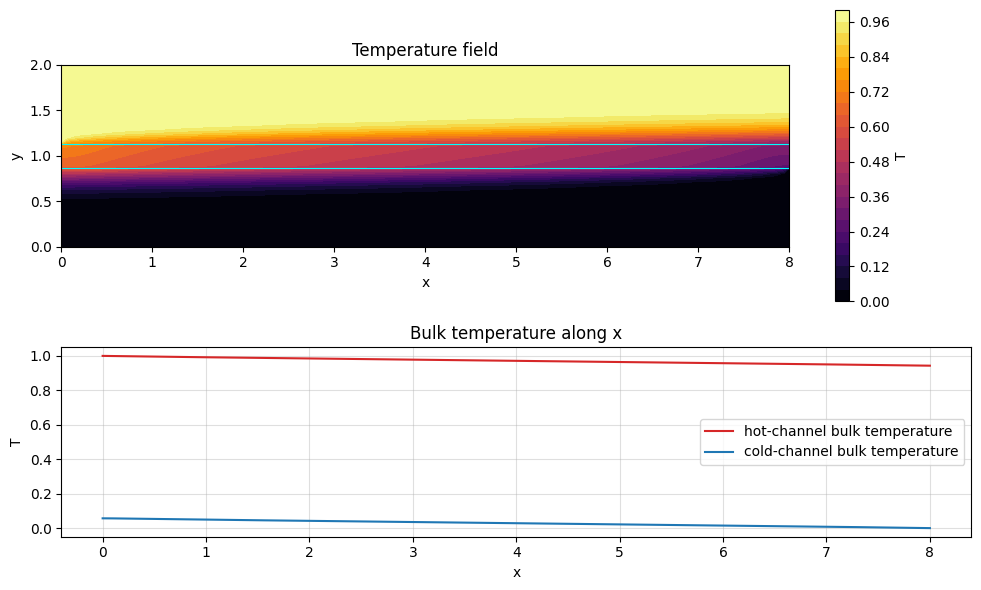

In [3]:
# reference case
r = solve(Re=50, Pr=8, ks_kf=10, counter_flow=True)
T, u = r["T"], r["u"]
print(f"iterations = {r['iters']}, residual = {r['res']:.2e}")
print(f"hot outlet = {r['hot_out']:.4f}, cold outlet = {r['cold_out']:.4f}")
print(f"q_hot = {r['q_hot']:.5f}, q_cold = {r['q_cold']:.5f}, effectiveness = {r['eff']:.4f}")

# Fig: velocity profile and zones
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(u[:, 0], y)
ax[0].axhline(y[n_cold], color="k", lw=0.8)
ax[0].axhline(y[n_cold + n_wall], color="k", lw=0.8)
ax[0].set(xlabel="u", ylabel="y", title="Velocity profile")
ax[1].contourf(X, Y, zone, levels=[-0.5, 0.5, 1.5, 2.5], colors=["#5da5da", "#b0b0b0", "#f17cb0"])
ax[1].set(xlabel="x", ylabel="y", title="Zones: cold / wall / hot", aspect="equal")
plt.tight_layout(); plt.show()

# Fig: convergence
plt.figure(figsize=(7, 3.5))
plt.semilogy(r["history"])
plt.xlabel("iteration"); plt.ylabel(r"$\max|T^{n+1}-T^n|$")
plt.title("Convergence to steady state"); plt.grid(alpha=0.4)
plt.show()

# Fig: temperature field and bulk temperatures
fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1.3]})
cf = ax[0].contourf(X, Y, T, levels=30, cmap="inferno")
ax[0].contour(X, Y, zone, levels=[0.5, 1.5], colors="cyan", linewidths=0.8)
plt.colorbar(cf, ax=ax[0], label="T")
ax[0].set(xlabel="x", ylabel="y", title="Temperature field", aspect="equal")
ax[1].plot(x, r["hot_bulk"], color="#d62728", label="hot-channel bulk temperature")
ax[1].plot(x, r["cold_bulk"], color="#1f77b4", label="cold-channel bulk temperature")
ax[1].set(xlabel="x", ylabel="T", title="Bulk temperature along x")
ax[1].legend(); ax[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

Sweeps: Re, Pr, ks/kf, flow arrangement

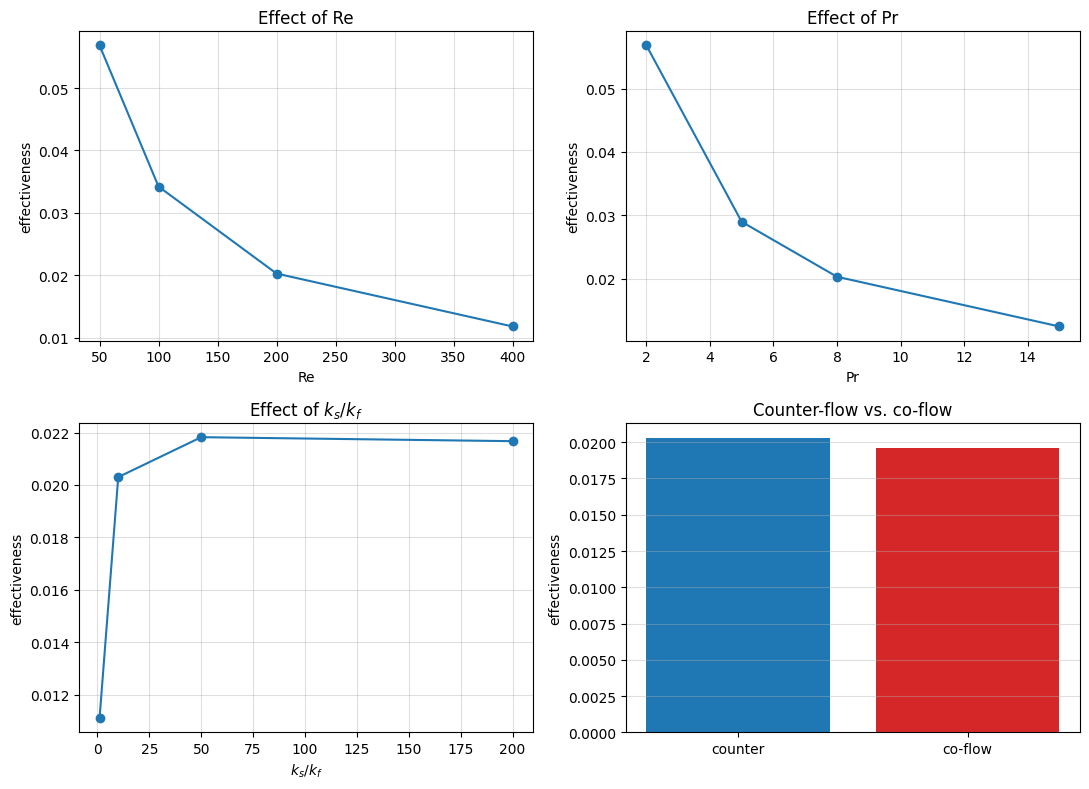

In [4]:
# parametric sweeps (base: Re=200, Pr=8, ks/kf=10, counter-flow); takes about a minute
base = dict(Re=200, Pr=8.0, ks_kf=10.0, counter_flow=True)
run = lambda **kw: solve(**{**base, **kw})["eff"]

Re_list, Pr_list, ks_list = [50, 100, 200, 400], [2, 5, 8, 15], [1, 10, 50, 200]
eff_Re = [run(Re=v) for v in Re_list]
eff_Pr = [run(Pr=float(v)) for v in Pr_list]
eff_ks = [run(ks_kf=float(v)) for v in ks_list]
eff_flow = [run(counter_flow=True), run(counter_flow=False)]

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
for a, xs, ys, xl, t in [(ax[0, 0], Re_list, eff_Re, "Re", "Effect of Re"),
                         (ax[0, 1], Pr_list, eff_Pr, "Pr", "Effect of Pr"),
                         (ax[1, 0], ks_list, eff_ks, "$k_s/k_f$", "Effect of $k_s/k_f$")]:
    a.plot(xs, ys, "o-")
    a.set(xlabel=xl, ylabel="effectiveness", title=t); a.grid(alpha=0.4)
ax[1, 1].bar(["counter", "co-flow"], eff_flow, color=["#1f77b4", "#d62728"])
ax[1, 1].set(ylabel="effectiveness", title="Counter-flow vs. co-flow"); ax[1, 1].grid(alpha=0.4, axis="y")
plt.tight_layout(); plt.show()

Outlet temperature and effectiveness vs Re

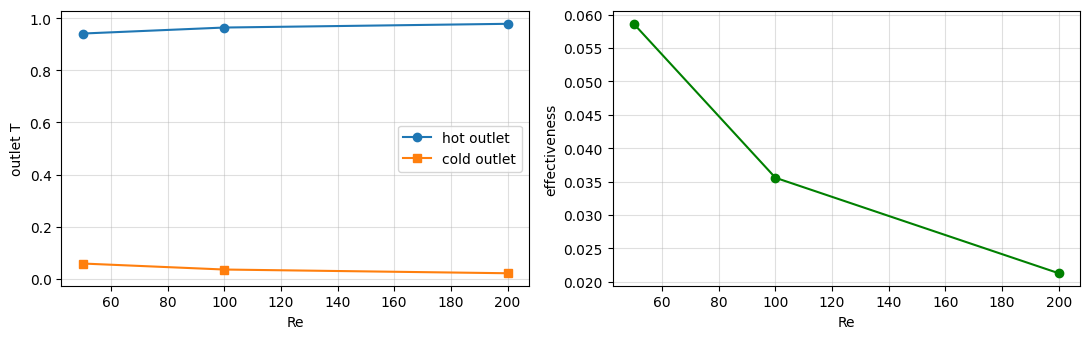

In [5]:
# Re sweep with ks/kf = 20
Res = [50, 100, 200]
runs = [solve(Re=v, ks_kf=20.0) for v in Res]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(Res, [q["hot_out"] for q in runs], "o-", label="hot outlet")
ax[0].plot(Res, [q["cold_out"] for q in runs], "s-", label="cold outlet")
ax[0].set(xlabel="Re", ylabel="outlet T"); ax[0].legend(); ax[0].grid(alpha=0.4)
ax[1].plot(Res, [q["eff"] for q in runs], "o-", color="green")
ax[1].set(xlabel="Re", ylabel="effectiveness"); ax[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()